## Identifying Pneumonia from Chest X Ray Images

Data source: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia?resource=download

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers

In [3]:
train_dir = 'archive/chest_xray/train/'
val_dir = 'archive/chest_xray/val/'
test_dir = 'archive/chest_xray/test/'

In [5]:
img_height = 128
img_width = 128
batch_size = 32

In [6]:
train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    color_mode='grayscale',
    image_size = (img_height, img_width),
    batch_size = batch_size
)

val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    val_dir,
    color_mode='grayscale',
    image_size = (img_height, img_width),
    batch_size = batch_size
)

test_ds = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    color_mode='grayscale',
    image_size = (img_height, img_width),
    batch_size = batch_size
)

Found 5216 files belonging to 2 classes.
Found 16 files belonging to 2 classes.
Found 624 files belonging to 2 classes.


In [8]:
train_ds.class_names

['NORMAL', 'PNEUMONIA']

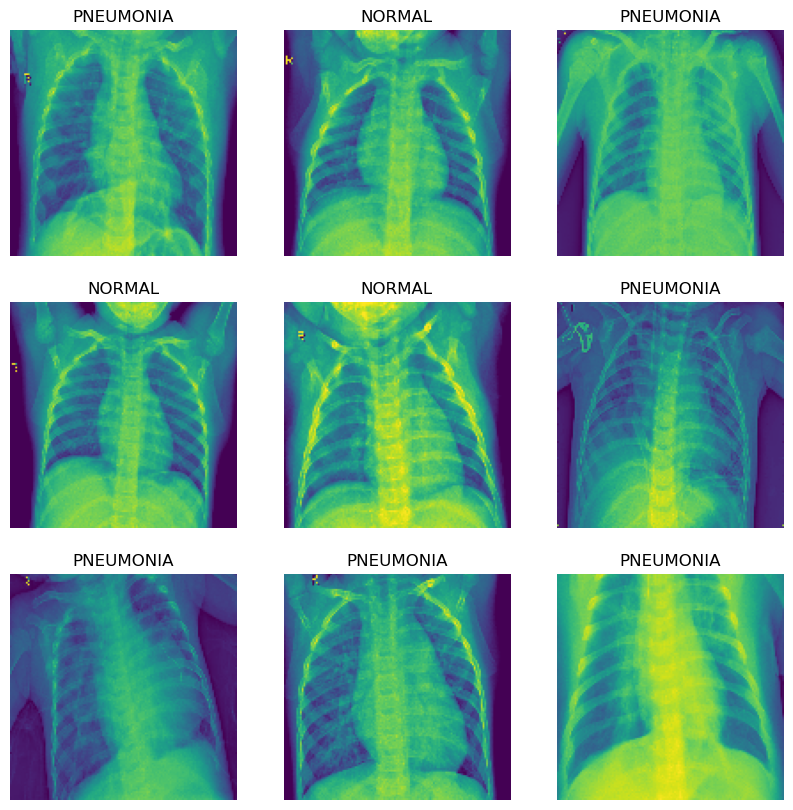

In [9]:
plt.figure(figsize=(10,10))
for images, labels in train_ds.take(1):
    for i in range(9):
        plt.subplot(3, 3, i+1)
        plt.imshow(np.squeeze(images[i].numpy().astype('uint8')))
        plt.title(train_ds.class_names[labels[i]])
        plt.axis('off')
plt.show()

In [10]:
AUTOTUNE = tf.data.experimental.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [13]:
model = tf.keras.Sequential([
    layers.Rescaling(1./255),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(2, activation='sigmoid')
])

In [14]:
model.compile(
    optimizer = 'adam',
    loss = tf.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics = ['accuracy']
)

In [15]:
epochs = 10

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10


D:\miniconda3\envs\tfenv\lib\site-packages\keras\src\backend\tensorflow\nn.py:717: UserWarning: "`sparse_categorical_crossentropy` received `from_logits=True`, but the `output` argument was produced by a Softmax activation and thus does not represent logits. Was this intended?
  output, from_logits = _get_logits(


163/163 ━━━━━━━━━━━━━━━━━━━━ 83s 492ms/step - accuracy: 0.8829 - loss: 0.2666 - val_accuracy: 0.6250 - val_loss: 0.8840
Epoch 2/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 33s 201ms/step - accuracy: 0.9500 - loss: 0.1370 - val_accuracy: 1.0000 - val_loss: 0.1267
Epoch 3/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 208ms/step - accuracy: 0.9640 - loss: 0.0980 - val_accuracy: 1.0000 - val_loss: 0.0819
Epoch 4/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 203ms/step - accuracy: 0.9686 - loss: 0.0827 - val_accuracy: 1.0000 - val_loss: 0.0590
Epoch 5/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 35s 212ms/step - accuracy: 0.9741 - loss: 0.0708 - val_accuracy: 1.0000 - val_loss: 0.0424
Epoch 6/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 40s 205ms/step - accuracy: 0.9801 - loss: 0.0568 - val_accuracy: 1.0000 - val_loss: 0.0807
Epoch 7/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 203ms/step - accuracy: 0.9812 - loss: 0.0537 - val_accuracy: 1.0000 - val_loss: 0.0194
Epoch 8/10
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 205ms/step - accuracy: 0.9826 - loss: 0.0467 - val

In [17]:
model.evaluate(test_ds)

20/20 ━━━━━━━━━━━━━━━━━━━━ 7s 356ms/step - accuracy: 0.8349 - loss: 1.1113


[1.1113234758377075, 0.8349359035491943]